In [ ]:
!pip install cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [ ]:
import os
# import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Dataset
DATASET_ROOT_PATH = '/content/drive/MyDrive/Uniandes/ImagenesEcografia'

MODEL_TYPE = 'densenet'

# Parámetros de entrenamiento
BATCH_SIZE = 16
IMG_SIZE = 224
NUM_CLASSES = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# Reproducibilidad
torch.manual_seed(SEED)
np.random.seed(SEED)

#PREPROCESAMIENTO  DE LAS IMAGENES
def preprocess_ultrasound(img_path, img_size=224):
    """
    1. Recorte (ROI) para quitar letras.
    2. Median Blur para quitar ruido speckle.
    3. CLAHE para resaltar la textura del hígado.
    """
    try:
        # Leer en escala de grises
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: return None

        # RECORTE AUTOMÁTICO (ROI)
        _, thresh = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            # Margen del 5% para evitar bordes blancos
            m = int(w * 0.05)
            if w > 2*m and h > 2*m:
                img = img[y+m : y+h-m, x+m : x+w-m]

        if img.size == 0:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Fallback

        # REDUCCIÓN DE SPECKLE (Suavizado ligero)
        img = cv2.medianBlur(img, 5)

        # MEJORA DE TEXTURA (CLAHE) -
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img = clahe.apply(img)

        # RESIZE Y CAMBIO A RGB
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) # 3 Canales
        img = cv2.resize(img, (img_size, img_size))

        # Normalización a 0-1 y transposición (HWC -> CHW)
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)

        return torch.tensor(img, dtype=torch.float32)
    except Exception as e:
        print(f"Error en {img_path}: {e}")
        return None

# CREAR EL DATAFRAME DESDE LAS CARPETAS (Nombre de carpeta es el estadio)
def create_dataframe_from_folders(root_path):
    data = []
    classes = ['F0', 'F1', 'F2', 'F3', 'F4']

    if not os.path.exists(root_path):
        print(f"No existe la ruta {root_path}")
        return pd.DataFrame({'filename': [], 'label': []})

    for label_int, folder_name in enumerate(classes):
        folder_path = os.path.join(root_path, folder_name)
        if not os.path.exists(folder_path):
            continue

        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.png','.jpeg'))]
        for f in files:
            data.append({
                'filename': os.path.join(folder_name, f), # Ruta relativa
                'label': label_int
            })

    return pd.DataFrame(data)

class FibrosisDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        full_path = os.path.join(self.root_dir, row['filename'])

        image_tensor = preprocess_ultrasound(full_path, IMG_SIZE)

        # Manejo de error si la imagen está corrupta
        if image_tensor is None:
            image_tensor = torch.zeros((3, IMG_SIZE, IMG_SIZE), dtype=torch.float32)

        label = int(row['label'])

        if self.transform:
            image_tensor = self.transform(image_tensor)

        return image_tensor, label

# Transformaciones (Aumentación de datos en memoria)
transforms_dict = {
    'train': transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# DEFINICIÓN DE ARQUITECTURAS

class TextureNetwork(nn.Module):
    def __init__(self, model_type='efficientnet', num_classes=5):
        super(TextureNetwork, self).__init__()
        self.model_type = model_type

        # --- SELECCIÓN DEL BACKBONE ---
        if model_type == 'efficientnet':
            self.base = models.efficientnet_b0(pretrained=True)
            self.features = self.base.features
            # EfficientNet B0 output channels = 1280
            out_channels = 1280

        elif model_type == 'densenet':
            self.base = models.densenet121(pretrained=True)
            self.features = self.base.features
            # DenseNet121 output channels = 1024
            out_channels = 1024

        # --- CAPA DE TEXTURA (Concat Pooling) ---
        # Promedio + Máximo para capturar patrones generales y picos de textura
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # --- CLASIFICADOR (HEAD) ---
        # Multiplicamos por 2 porque concatenamos avg y max
        input_dim = out_channels * 2

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(input_dim),
            nn.Dropout(p=0.5),
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)

        if self.model_type == 'densenet':
            # FIX: Removed inplace=True to prevent RuntimeError with GradCAM
            x = nn.functional.relu(x)

        x_avg = self.avg_pool(x)
        x_max = self.max_pool(x)

        # Concatenación de características
        x = torch.cat((x_avg, x_max), dim=1)
        x = self.classifier(x)
        return x


# PREPARACIÓN Y EJECUCIÓN

# Carga de Datos
full_df = create_dataframe_from_folders(DATASET_ROOT_PATH)

if len(full_df) == 0:
    print("No se encontraron imágenes. Revisa la ruta DATASET_ROOT_PATH.")
else:
    print(f"Total imágenes: {len(full_df)}")

    # B. Split Estratificado
    train_df, val_df = train_test_split(full_df, test_size=0.2, stratify=full_df['label'], random_state=SEED)

    # C. DataLoaders
    train_ds = FibrosisDataset(train_df, DATASET_ROOT_PATH, transform=transforms_dict['train'])
    val_ds = FibrosisDataset(val_df, DATASET_ROOT_PATH, transform=transforms_dict['val'])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # D. Pesos de Clase (Para el desbalance)
    class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    print(f"Pesos de Clase: {class_weights}")

    # E. Inicializar Modelo
    model = TextureNetwork(model_type=MODEL_TYPE, num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # --- FUNCIÓN DE BUCLE DE ENTRENAMIENTO ---
    def train_epoch(model, loader, optimizer, is_train=True):
        if is_train: model.train()
        else: model.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        with torch.set_grad_enabled(is_train):
            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                if is_train: optimizer.zero_grad()

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                if is_train:
                    loss.backward()
                    optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        return running_loss / total, 100 * correct / total

    #  WARM-UP (Congelado)
    print(f"\nINICIANDO WARM-UP (5 Épocas) - {MODEL_TYPE.upper()}")
    for param in model.features.parameters():
        param.requires_grad = False

    optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

    for epoch in range(5):
        t_loss, t_acc = train_epoch(model, train_loader, optimizer, True)
        v_loss, v_acc = train_epoch(model, val_loader, optimizer, False)
        print(f"Epoch {epoch+1}/5 | Train Loss: {t_loss:.3f} | Val Acc: {v_acc:.2f}%")

    print("Warm-up finalizado.")


Total imágenes: 1008
Pesos de Clase: tensor([1.1041, 0.7825, 1.3661, 1.3433, 0.7463])

INICIANDO WARM-UP (5 Épocas) - DENSENET


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 | Train Loss: 1.409 | Val Acc: 47.52%
Epoch 2/5 | Train Loss: 1.117 | Val Acc: 62.38%
Epoch 3/5 | Train Loss: 1.019 | Val Acc: 64.85%
Epoch 4/5 | Train Loss: 0.908 | Val Acc: 62.87%
Epoch 5/5 | Train Loss: 0.994 | Val Acc: 64.85%
Warm-up finalizado.


In [ ]:

# FINE-TUNING (Descongelado)

print(f"\n INICIANDO FINE-TUNING (20 Épocas) - {MODEL_TYPE.upper()}")

# 1. Descongelar toda la red
for param in model.features.parameters():
    param.requires_grad = True

# 2. Definir optimizador con LR bajo
optimizer = optim.Adam(model.parameters(), lr=5e-5)

# 3. Definir Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_acc = 0.0

# 4. Bucle de entrenamiento
for epoch in range(20):
    t_loss, t_acc = train_epoch(model, train_loader, optimizer, True)
    v_loss, v_acc = train_epoch(model, val_loader, optimizer, False)

    # El scheduler monitorea la pérdida de validación
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(v_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Se imprime el cambio de LR si ocurre
    lr_msg = ""
    if current_lr != prev_lr:
        lr_msg = f" | LR reducido a {current_lr:.1e}"

    print(f"Ep {epoch+1}/20 | T.Loss: {t_loss:.3f} | V.Loss: {v_loss:.3f} | V.Acc: {v_acc:.2f}%{lr_msg}")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), f'best_fibrosis_{MODEL_TYPE}.pth')
        print("  Modelo guardado (Mejor precisión)")

print(f"\n Entrenamiento finalizado. Mejor Precisión: {best_acc:.2f}%")


 INICIANDO FINE-TUNING (20 Épocas) - DENSENET
Ep 1/20 | T.Loss: 0.890 | V.Loss: 0.759 | V.Acc: 70.30%
  Modelo guardado (Mejor precisión)
Ep 2/20 | T.Loss: 0.755 | V.Loss: 0.709 | V.Acc: 71.78%
  Modelo guardado (Mejor precisión)
Ep 3/20 | T.Loss: 0.639 | V.Loss: 0.684 | V.Acc: 73.76%
  Modelo guardado (Mejor precisión)
Ep 4/20 | T.Loss: 0.550 | V.Loss: 0.633 | V.Acc: 77.23%
  Modelo guardado (Mejor precisión)
Ep 5/20 | T.Loss: 0.444 | V.Loss: 0.587 | V.Acc: 78.22%
  Modelo guardado (Mejor precisión)
Ep 6/20 | T.Loss: 0.441 | V.Loss: 0.501 | V.Acc: 82.18%
  Modelo guardado (Mejor precisión)
Ep 7/20 | T.Loss: 0.339 | V.Loss: 0.490 | V.Acc: 82.18%
Ep 8/20 | T.Loss: 0.345 | V.Loss: 0.496 | V.Acc: 84.16%
  Modelo guardado (Mejor precisión)
Ep 9/20 | T.Loss: 0.308 | V.Loss: 0.433 | V.Acc: 84.65%
  Modelo guardado (Mejor precisión)
Ep 10/20 | T.Loss: 0.267 | V.Loss: 0.437 | V.Acc: 86.63%
  Modelo guardado (Mejor precisión)
Ep 11/20 | T.Loss: 0.255 | V.Loss: 0.384 | V.Acc: 89.11%
  Modelo gu

In [ ]:
torch.save(model.state_dict(), f'best_fibrosis_final{MODEL_TYPE}.pth')

Generando matriz de confusión...


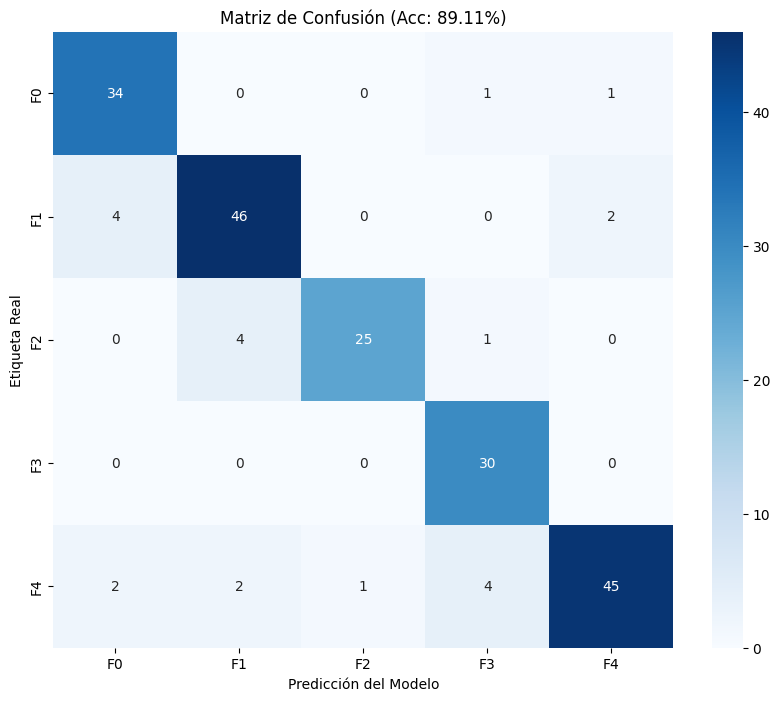


--- REPORTE CLÍNICO DETALLADO ---
              precision    recall  f1-score   support

          F0       0.85      0.94      0.89        36
          F1       0.88      0.88      0.88        52
          F2       0.96      0.83      0.89        30
          F3       0.83      1.00      0.91        30
          F4       0.94      0.83      0.88        54

    accuracy                           0.89       202
   macro avg       0.89      0.90      0.89       202
weighted avg       0.90      0.89      0.89       202



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    print("Generando matriz de confusión...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 1. Matriz Gráfica
    cm = confusion_matrix(all_labels, all_preds)
    classes = ['F0', 'F1', 'F2', 'F3', 'F4']

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Etiqueta Real')
    plt.title(f'Matriz de Confusión (Acc: {100*sum(np.array(all_preds)==np.array(all_labels))/len(all_labels):.2f}%)')
    plt.show()

    # 2. Reporte Numérico
    print("\n--- REPORTE CLÍNICO DETALLADO ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

# Cargar el mejor modelo guardado antes de evaluar
model.load_state_dict(torch.load(f'best_fibrosis_final{MODEL_TYPE}.pth'))
evaluate_model(model, val_loader)


In [ ]:
def predict_single_image(image_path, model_path):
    # 1. Configurar modelo
    model = TextureNetwork(model_type=MODEL_TYPE, num_classes=NUM_CLASSES)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()

    # 2. Preprocesar la imagen (Lectura + Limpieza)
    img_tensor = preprocess_ultrasound(image_path)

    if img_tensor is None:
        print("Error al leer la imagen.")
        return

    # Se debe aplicarla misma normalización que el entrenamiento
    normalize = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    img_tensor = normalize(img_tensor)

    # Añadir dimensión de batch (1, C, H, W)
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    # 3. Predecir
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        score, predicted = torch.max(probabilities, 1)

    class_map = ['F0 (Sano)', 'F1 (Fibrosis Leve)', 'F2 (Fibrosis Moderada)',
                 'F3 (Fibrosis Severa)', 'F4 (Cirrosis)']

    print(f"Archivo: {os.path.basename(image_path)}")
    print(f"Diagnóstico: {class_map[predicted.item()]}")
    print(f"Confianza: {score.item()*100:.2f}%")

    # Mostrar probabilidades por clase
    print("\nDesglose de probabilidades:")
    probs = probabilities.cpu().numpy()[0]
    for i, p in enumerate(probs):
        bar = "█" * int(p * 20)
        print(f"  {class_map[i].split(' ')[0]}: {p*100:.2f}% {bar}")

In [17]:
Im_F0="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F0/IM-0001-0003_3.jpg"
Im_F1="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F1/IM-0001-0001-0003.jpg"
Im_F2="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F2/IM-0001-0001_2.jpg"
Im_F3="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F3/Captura de pantalla 2025-10-08 a la(s) 3.43.38 p.m..png"
Im_F4="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F4/IM-0001-0001 (2).jpg"

predict_single_image(Im_F0, f'best_fibrosis_{MODEL_TYPE}.pth')

Archivo: IM-0001-0003_3.jpg
Diagnóstico: F0 (Sano)
Confianza: 91.45%

Desglose de probabilidades:
  F0: 91.45% ██████████████████
  F1: 1.50% 
  F2: 4.57% 
  F3: 2.20% 
  F4: 0.28% 


Test con todo el dataset de la fundacion Santa Fe

Evaluando sobre el dataset completo: 1008 imágenes
 Generando predicciones.

Reporte detallado guardado en: reporte_predicciones_completo.csv


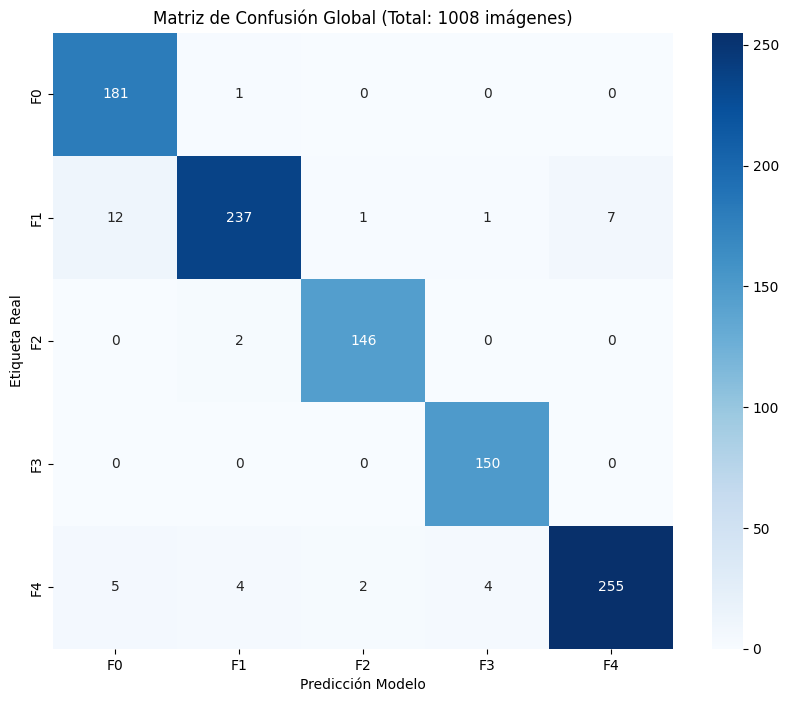


--- MÉTRICAS GLOBALES ---
              precision    recall  f1-score   support

          F0       0.91      0.99      0.95       182
          F1       0.97      0.92      0.94       258
          F2       0.98      0.99      0.98       148
          F3       0.97      1.00      0.98       150
          F4       0.97      0.94      0.96       270

    accuracy                           0.96      1008
   macro avg       0.96      0.97      0.96      1008
weighted avg       0.96      0.96      0.96      1008



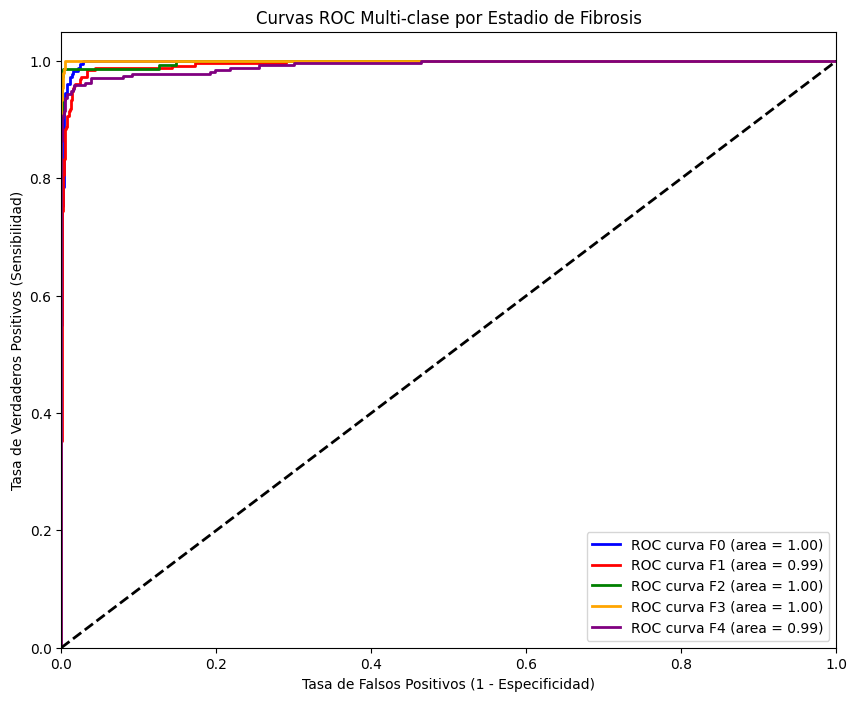

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# CARGA DE DATOS TOTALES
# Generamos el dataframe con TODO el dataset (sin dividir train/val)
full_df = create_dataframe_from_folders(DATASET_ROOT_PATH)
print(f"Evaluando sobre el dataset completo: {len(full_df)} imágenes")

# Creamos el Dataset y Loader (¡IMPORTANTE: shuffle=False para mantener el orden!)
eval_dataset = FibrosisDataset(full_df, DATASET_ROOT_PATH, transform=transforms_dict['val'])
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Cargamos el mejor modelo guardado
model = TextureNetwork(model_type=MODEL_TYPE, num_classes=NUM_CLASSES)
model_path = f'best_fibrosis_{MODEL_TYPE}.pth'
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# ==========================================
# 2. BUCLE DE PREDICCIÓN (INFERENCIA)
# ==========================================
print(" Generando predicciones.")

all_preds = []
all_labels = []
all_probs = [] # Para guardar probabilidades de cada clase (útil para curvas ROC)

with torch.no_grad():
    for inputs, labels in eval_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Forward pass
        outputs = model(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        # Guardar datos en listas (moviendo a CPU)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# GENERAR REPORTE CSV (Excel)
# Convertir a array
all_probs = np.array(all_probs)

# Crear DataFrame de resultados
results_df = full_df.copy()
results_df['pred_label'] = all_preds
results_df['is_correct'] = results_df['label'] == results_df['pred_label']

# Agregar columnas de probabilidad por clase
classes = ['F0', 'F1', 'F2', 'F3', 'F4']
for i, class_name in enumerate(classes):
    results_df[f'prob_{class_name}'] = all_probs[:, i]

# Guardar a archivo
csv_filename = 'reporte_predicciones_completo.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\nReporte detallado guardado en: {csv_filename}")

# 4. MÉTRICAS DE RENDIMIENTO

# A. Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Matriz de Confusión Global (Total: {len(full_df)} imágenes)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción Modelo')
plt.show()

# B. Reporte Numérico
print("\n--- MÉTRICAS GLOBALES ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# C. Curvas ROC (Receiver Operating Characteristic)
# Esto es vital para papers médicos: Muestra la relación entre Sensibilidad y Falsos Positivos
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(n_classes), colors):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curva {classes[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curvas ROC Multi-clase por Estadio de Fibrosis')
plt.legend(loc="lower right")
plt.show()

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.feature_maps = None
        self.gradients = None

        self.handlers = []
        self.handlers.append(target_layer.register_forward_hook(self.save_feature_maps))
        self.handlers.append(target_layer.register_full_backward_hook(self.save_gradients))

    def save_feature_maps(self, module, input, output):
        self.feature_maps = output.detach().clone()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()

    def generate_cam(self, input_tensor, target_class=None):
        input_tensor.requires_grad = True
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()

        one_hot_output = torch.zeros_like(output)
        one_hot_output[0][target_class] = 1

        output.backward(gradient=one_hot_output, retain_graph=True)

        # Generar Heatmap con los datos clonados
        gradients = self.gradients
        activations = self.feature_maps

        # Global Average Pooling de los gradientes
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Ponderación de mapas de características
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        # Promedio de canales
        heatmap = torch.mean(activations, dim=1).squeeze()

        # ReLU para quedarnos solo con la contribución positiva
        heatmap = F.relu(heatmap)

        # Normalizar
        if torch.max(heatmap) > 0:
            heatmap /= torch.max(heatmap)
        else:
            heatmap = torch.zeros_like(heatmap)

        return heatmap.cpu().numpy(), target_class, output

    def remove_hooks(self):
        """Elimina los hooks para liberar memoria al terminar"""
        for handle in self.handlers:
            handle.remove()

def overlay_heatmap(img_path, heatmap, img_size=224):
    """Mezcla la imagen original con el mapa de calor"""
    # 1. Cargar imagen original para visualización
    img = cv2.imread(img_path)
    img = cv2.resize(img, (img_size, img_size))

    # 2. Redimensionar el heatmap al tamaño de la imagen
    heatmap = cv2.resize(heatmap, (img_size, img_size))

    # 3. Colorear el heatmap (Uso JET: Rojo=Caliente, Azul=Frío)
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # 4. Superponer (0.5 imagen original + 0.5 mapa de calor)
    superimposed_img = heatmap_colored * 0.4 + img * 0.6

    # Devolver imagen lista para matplotlib (RGB)
    superimposed_img = np.uint8(superimposed_img)
    return cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

GENERACION DE IMAGEN CON GRAD-CAM

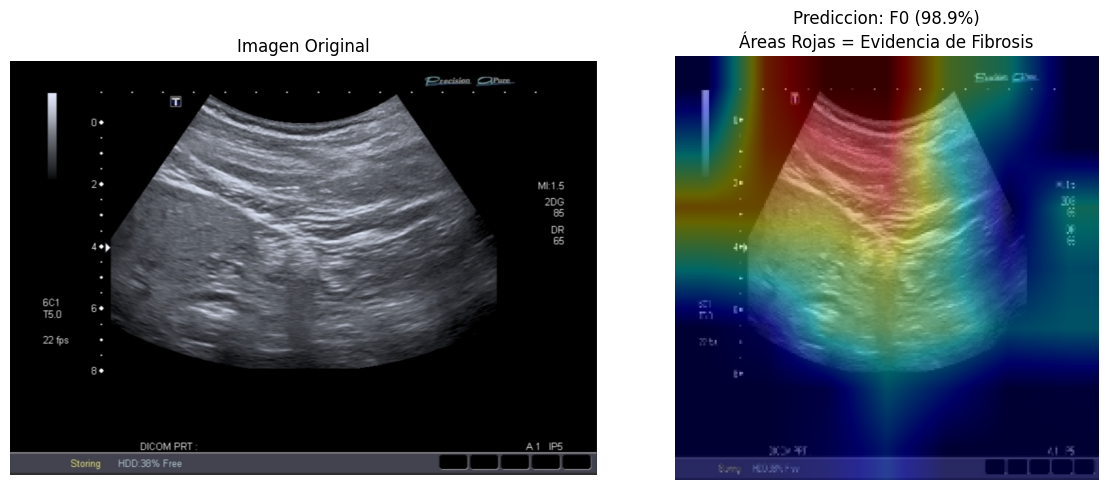

Diagnóstico: F0


In [19]:
TEST_IMAGE_PATH = '/content/drive/MyDrive/Uniandes/ImagenesEcografia/F3/Captura de pantalla 2025-10-08 a la(s) 3.43.38 p.m..png'

model = TextureNetwork(model_type=MODEL_TYPE, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(f'best_fibrosis_{MODEL_TYPE}.pth', map_location=DEVICE))
model.to(DEVICE)

if MODEL_TYPE == 'densenet':
    target_layer = model.features.norm5
else:
    target_layer = model.features[-1]

# Instanciar GradCAM
grad_cam = GradCAM(model, target_layer)

# Preprocesar imagen
input_tensor = preprocess_ultrasound(TEST_IMAGE_PATH)
if input_tensor is not None:
    input_tensor = input_tensor.unsqueeze(0).to(DEVICE) # Añadir Batch dimension
    input_tensor.requires_grad = True # Necesario para calcular gradientes

    # Generar Heatmap
    heatmap, pred_idx, scores = grad_cam.generate_cam(input_tensor)

    # Crear superposición
    viz_img = overlay_heatmap(TEST_IMAGE_PATH, heatmap)

    # MOSTRAR RESULTADOS
    classes = ['F0', 'F1', 'F2', 'F3', 'F4']
    prob = torch.nn.functional.softmax(scores, dim=1)[0][pred_idx].item()

    plt.figure(figsize=(12, 5))

    # Imagen Original
    plt.subplot(1, 2, 1)
    orig = cv2.imread(TEST_IMAGE_PATH)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    plt.imshow(orig)
    plt.title("Imagen Original")
    plt.axis('off')

    # Grad-CAM
    plt.subplot(1, 2, 2)
    plt.imshow(viz_img)
    plt.title(f"Prediccion: {classes[pred_idx]} ({prob*100:.1f}%)\nÁreas Rojas = Evidencia de Fibrosis")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Diagnóstico: {classes[pred_idx]}")
else:
    print("Error cargando la imagen para GradCAM")

In [20]:
Im_F0="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F0/IM-0001-0003_3.jpg"
Im_F1="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F1/IM-0001-0001-0003.jpg"
Im_F2="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F2/IM-0001-0001_2.jpg"
Im_F3="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F3/Captura de pantalla 2025-10-08 a la(s) 3.43.38 p.m..png"
Im_F4="/content/drive/MyDrive/Uniandes/ImagenesEcografia/F4/IM-0001-0001 (2).jpg"

predict_single_image(Im_F0, f'best_fibrosis_{MODEL_TYPE}.pth')

Archivo: IM-0001-0003_3.jpg
Diagnóstico: F0 (Sano)
Confianza: 91.45%

Desglose de probabilidades:
  F0: 91.45% ██████████████████
  F1: 1.50% 
  F2: 4.57% 
  F3: 2.20% 
  F4: 0.28% 
